In [1]:
import pandas as pd

In [2]:
# df = pd.read_parquet("part-00000-1dc0d1bc-3cdc-4fa2-a1dc-c9597cd083eb-c000.snappy.parquet")

In [3]:
# df.head(5)

In [4]:
# df2 = pd.read_parquet("part-00000-2785690b-ff9f-408f-b1bf-8eb8d2b2b92b-c000.snappy.parquet")
# df2.head(5)

In [5]:
# df3 = pd.read_json("raw_reviews_part_1 (1).jsonl", lines=True)
# import json

# payload_df = pd.json_normalize(df3["raw_payload"])

In [6]:
# payload_df

In [7]:
# df4 = pd.read_json("raw_reviews_part_1 (2).jsonl", lines=True)

# payload_df2 = pd.json_normalize(df4["raw_payload"])

In [8]:
# payload_df2

In [23]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB  
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\duyan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
data = pd.read_csv("output.csv")

In [5]:
data.head(5)

,review_id,imdb_id,content,rating,source_system
0,000524abf6de59d91f3e4a4375ec8415cc5a9cdf1fe595...,tt27543632,"For the first hour of the movie, I honestly di...",7.0,imdb
1,000a465558f22ae39464a9830ce91dbcd7786a76ab60ab...,tt7181546,"I actual like this film a lot, this film is no...",7.0,imdb
2,002c15fdae45738c4c9a43d5db9a73b2b00c5ddd4a19fa...,tt15239678,This movie is a spell binding experience. It i...,9.0,imdb
3,00356c43c1324f1f636c22fe9926ed43b1d843360c9c40...,tt15940132,This is the second movie i've watched from Ala...,3.0,imdb
4,00448ca2411ce6bb93ec8a1cab9b0d22b559be878078d7...,tt30144839,Horrible from start to finish. Clearly made to...,2.0,imdb


In [6]:
port_stem = PorterStemmer()
stop_words = stopwords.words('english')

def stemming(content):
    # Loại bỏ các đường dẫn liên kết (URLs)
    stemmed_content = re.sub(r'http\S+|www\S+|https\S+', '', str(content), flags=re.MULTILINE)
    # Loại bỏ kí tự nhắc đến tên người dùng
    stemmed_content = re.sub(r'\@\w+', '', content)
    # Lọc ký tự  và chuyển chữ thường
    stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()

    # Loại bỏ stopwords và đưa từ về từ gốc
    stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stop_words]
    stemmed_content = ' '.join(stemmed_content)

    return stemmed_content

In [7]:
data['stemmed_content'] = data['content'].apply(stemming)

In [8]:
# 1. Thay thế các chuỗi rỗng hoặc chỉ chứa toàn khoảng trắng thành NaN (để dễ dàng sử dụng hàm dropna)
data['stemmed_content'] = data['stemmed_content'] \
                                        .replace(r'^\s*$', np.nan, regex=True)
# 2. Xóa tất cả các dòng có giá trị NaN trong cột 'stemmed_content'
data.dropna(subset=['stemmed_content'], inplace=True)
# 3. Đặt lại chỉ mục (index) cho dataframe cho liền mạch sau khi các dòng đã bị xóa
data.reset_index(drop=True, inplace=True)
# In ra số lượng sau khi xóa để kiểm tra
print("Số lượng bản ghi dữ liệu sau khi xóa câu rỗng: ", len(data))

Số lượng bản ghi dữ liệu sau khi xóa câu rỗng:  70076


In [9]:
data["label"] = data["rating"].apply(
    lambda x: 1.0 if x >= 7.0 else(0.0 if pd.notna(x) else None)
)

In [10]:
data.head(5)

,review_id,imdb_id,content,rating,source_system,stemmed_content,label
0,000524abf6de59d91f3e4a4375ec8415cc5a9cdf1fe595...,tt27543632,"For the first hour of the movie, I honestly di...",7.0,imdb,first hour movi honestli even know felt cringe...,1.0
1,000a465558f22ae39464a9830ce91dbcd7786a76ab60ab...,tt7181546,"I actual like this film a lot, this film is no...",7.0,imdb,actual like film lot film hit miss like john w...,1.0
2,002c15fdae45738c4c9a43d5db9a73b2b00c5ddd4a19fa...,tt15239678,This movie is a spell binding experience. It i...,9.0,imdb,movi spell bind experi almost perfect amalgam ...,1.0
3,00356c43c1324f1f636c22fe9926ed43b1d843360c9c40...,tt15940132,This is the second movie i've watched from Ala...,3.0,imdb,second movi watch alan ritchson first playdat ...,0.0
4,00448ca2411ce6bb93ec8a1cab9b0d22b559be878078d7...,tt30144839,Horrible from start to finish. Clearly made to...,2.0,imdb,horribl start finish clearli made incit violen...,0.0


In [11]:
data["label"].value_counts(normalize=True)

label
1.0    0.674931
0.0    0.325069
Name: proportion, dtype: float64

In [12]:
data.groupby("source_system")["label"].value_counts(normalize=True)

source_system  label
imdb           1.0      0.674986
               0.0      0.325014
tmdb           1.0      0.600000
               0.0      0.400000
Name: proportion, dtype: float64

In [13]:
data_clean = data.dropna(subset=["stemmed_content", "label"])
X = data_clean["stemmed_content"]
Y = data_clean["label"]

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [15]:
print(X_train.shape, Y_train.shape)

(54240,) (54240,)


In [16]:
print(Y_train.value_counts())

label
1.0    36608
0.0    17632
Name: count, dtype: int64


In [17]:
print(X_test.shape, Y_test.shape)

(13561,) (13561,)


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    stop_words="english",
    min_df=3        
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Mô hình baseline: Naive Bayes
Naive Bayes được chọn làm mô hình **baseline** vì:
- Đơn giản, nhanh, dễ giải thích
- Hoạt động tốt với dữ liệu văn bản TF-IDF
- **ComplementNB** đặc biệt phù hợp với dữ liệu **mất cân bằng** (imbalanced)
- Kết quả của Naive Bayes sẽ là "ngưỡng cần" (baseline) để so sánh các mô hình phức tạp hơn

In [19]:
param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0]
}
grid_search_nb = GridSearchCV(
    ComplementNB(),
    param_grid_nb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search_nb.fit(X_train_vec, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ComplementNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes

In [20]:
print("--- Naive Bayes (Baseline) Tuning Results ---")
print("Best Parameters:", grid_search_nb.best_params_)
print("Best F1-Macro Score (CV):", grid_search_nb.best_score_)

--- Naive Bayes (Baseline) Tuning Results ---
Best Parameters: {'alpha': 0.01}
Best F1-Macro Score (CV): 0.8027542725894827


In [21]:
# Đánh giá Naive Bayes trên tập Test
best_model_nb = grid_search_nb.best_estimator_
y_pred_nb = best_model_nb.predict(X_test_vec)

print("--- Final Naive Bayes (Baseline) Evaluation on Test Set ---")
print(classification_report(Y_test, y_pred_nb))

# ROC-AUC: ComplementNB hỗ trợ predict_proba nên có thể tính trực tiếp
y_prob_nb = best_model_nb.predict_proba(X_test_vec)[:, 1]
print("ROC-AUC Score:", roc_auc_score(Y_test, y_prob_nb))

--- Final Naive Bayes (Baseline) Evaluation on Test Set ---
              precision    recall  f1-score   support

         0.0       0.67      0.90      0.77      4408
         1.0       0.94      0.79      0.86      9153

    accuracy                           0.82     13561
   macro avg       0.81      0.84      0.81     13561
weighted avg       0.85      0.82      0.83     13561

ROC-AUC Score: 0.9225285740317406


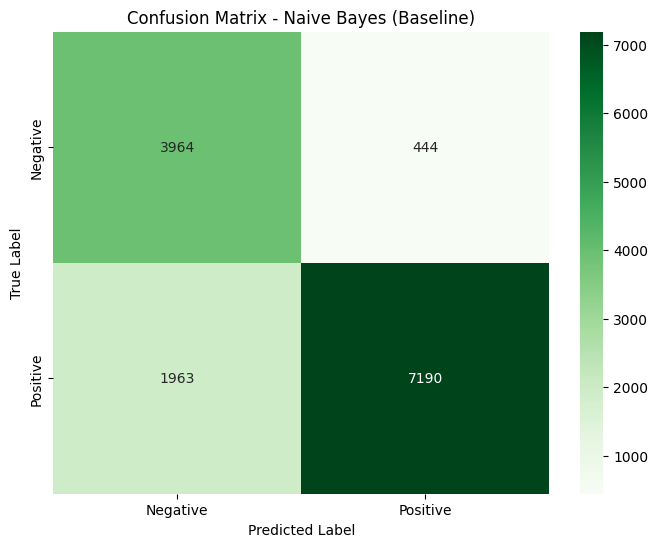

In [24]:
cm_nb = confusion_matrix(Y_test, y_pred_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Naive Bayes (Baseline)')
plt.show()


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ["saga"]
}

grid_search = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=2000), param_grid, cv=5, scoring='f1_macro')
grid_search.fit(X_train_vec, Y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Best Parameters: {'C': 1, 'solver': 'saga'}
Best Score: 0.8516700181532585


In [26]:
best_model_lr = grid_search.best_estimator_
y_pred_final = best_model_lr.predict(X_test_vec)

In [27]:
print("--- Final LR Evaluation on Test Set ---")
print(classification_report(Y_test, y_pred_final))
print("ROC-AUC Score:", roc_auc_score(Y_test, best_model_lr.predict_proba(X_test_vec)[:, 1]))

--- Final LR Evaluation on Test Set ---
              precision    recall  f1-score   support

         0.0       0.77      0.87      0.81      4408
         1.0       0.93      0.88      0.90      9153

    accuracy                           0.87     13561
   macro avg       0.85      0.87      0.86     13561
weighted avg       0.88      0.87      0.87     13561

ROC-AUC Score: 0.9408452407083214


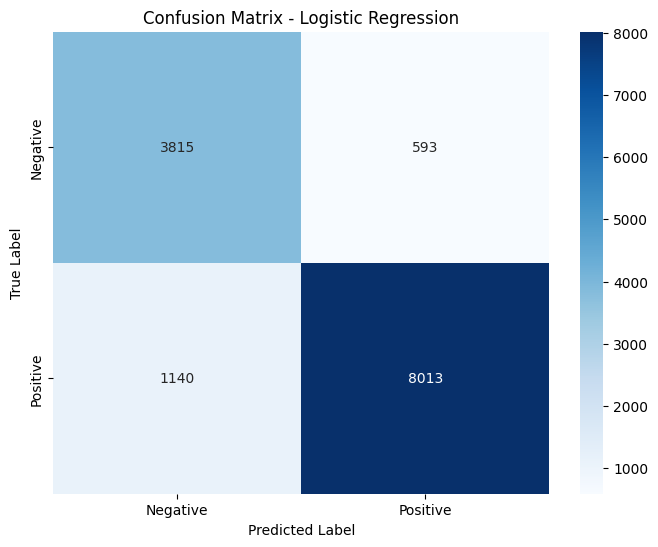

In [28]:
cm = confusion_matrix(Y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


In [29]:
compare_data = {
    'Model': ['Naive Bayes (Baseline)', 'Logistic Regression'],
    'F1-Macro (CV)': [grid_search_nb.best_score_, grid_search.best_score_],
    'ROC-AUC (Test)': [
        roc_auc_score(Y_test, y_prob_nb),
        roc_auc_score(Y_test, best_model_lr.predict_proba(X_test_vec)[:, 1])
    ]
}
df_compare = pd.DataFrame(compare_data)
print(df_compare.to_string(index=False))


                 Model  F1-Macro (CV)  ROC-AUC (Test)
Naive Bayes (Baseline)       0.802754        0.922529
   Logistic Regression       0.851670        0.940845
